# 📊 Laboratorio 03: Análisis Profundo de Correlaciones Fisiológicas
### Matriz de Correlación Paramétrica y No Paramétrica con Datos Limpios DVC

---

## 🎯 Objetivo
Explorar rigurosamente las interacciones entre las variables clave de la telemetría Garmin:
1. **Matriz de Pearson y Spearman** cruzando sueño, esfuerzo, calorías y estrés.
2. **Correlaciones de Retardo (Lags)**: Impacto de las variables del día anterior sobre la recuperación de hoy.
3. **Heatmaps de Relación Autonómica**: Sueño profundo vs. HRV, estrés vs. frecuencia cardíaca en reposo.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

# Carga directa de la tabla limpia DVC
dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

core_metrics = [
    "resting_heart_rate",
    "running_avg_hr",
    "gym_avg_hr",
    "walking_avg_hr",
    "total_sleep_hours",
    "sleep_score",
    "active_kilocalories",
    "resting_kilocalories",
    "total_kilocalories",
    "total_steps",
    "daily_avg_stress",
    "hrv_rmssd",
]

df_core = df[core_metrics].copy()
print(f"📊 Dataset DVC listo para análisis: {df_core.shape[0]} registros x {df_core.shape[1]} variables clave.")
df_core.describe().T[["mean", "std", "min", "50%", "max"]]


📊 Dataset DVC listo para análisis: 11 registros x 12 variables clave.


,mean,std,min,50%,max
resting_heart_rate,57.909091,2.022600,55.00,58.00,61.0
running_avg_hr,153.272727,14.100290,141.00,141.00,168.0
gym_avg_hr,110.363636,1.566699,109.00,109.00,112.0
walking_avg_hr,119.000000,0.000000,119.00,119.00,119.0
total_sleep_hours,6.582727,0.851917,4.87,6.75,7.8
sleep_score,80.909091,9.038302,60.00,83.00,90.0
active_kilocalories,341.909091,245.673952,43.00,258.00,845.0
resting_kilocalories,1754.181818,272.142175,1151.00,1876.00,1876.0
total_kilocalories,2096.090909,430.458698,1315.00,2134.00,2721.0
total_steps,8861.727273,4972.368612,2718.00,8127.00,20099.0


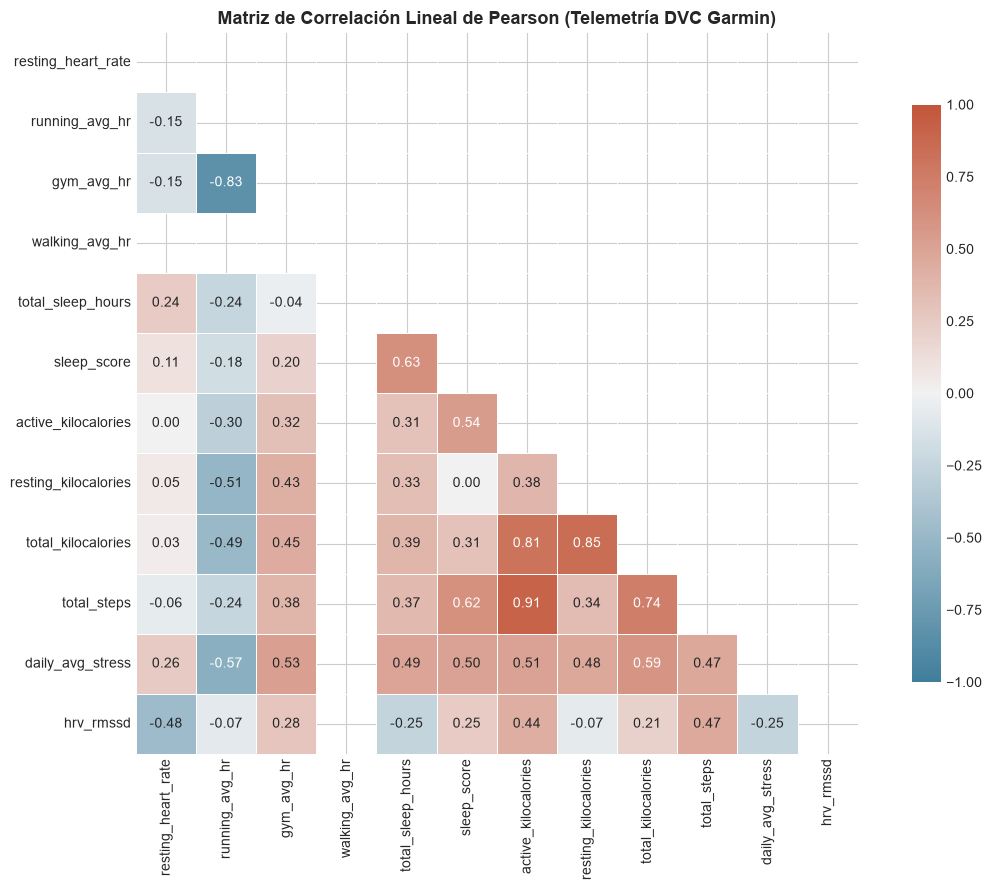

In [2]:
# 1. Matriz de Correlación de Pearson
corr_pearson = df_core.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_pearson,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.7,
    cbar_kws={"shrink": 0.8},
    annot=True,
    fmt=".2f",
    ax=ax,
)
ax.set_title("Matriz de Correlación Lineal de Pearson (Telemetría DVC Garmin)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


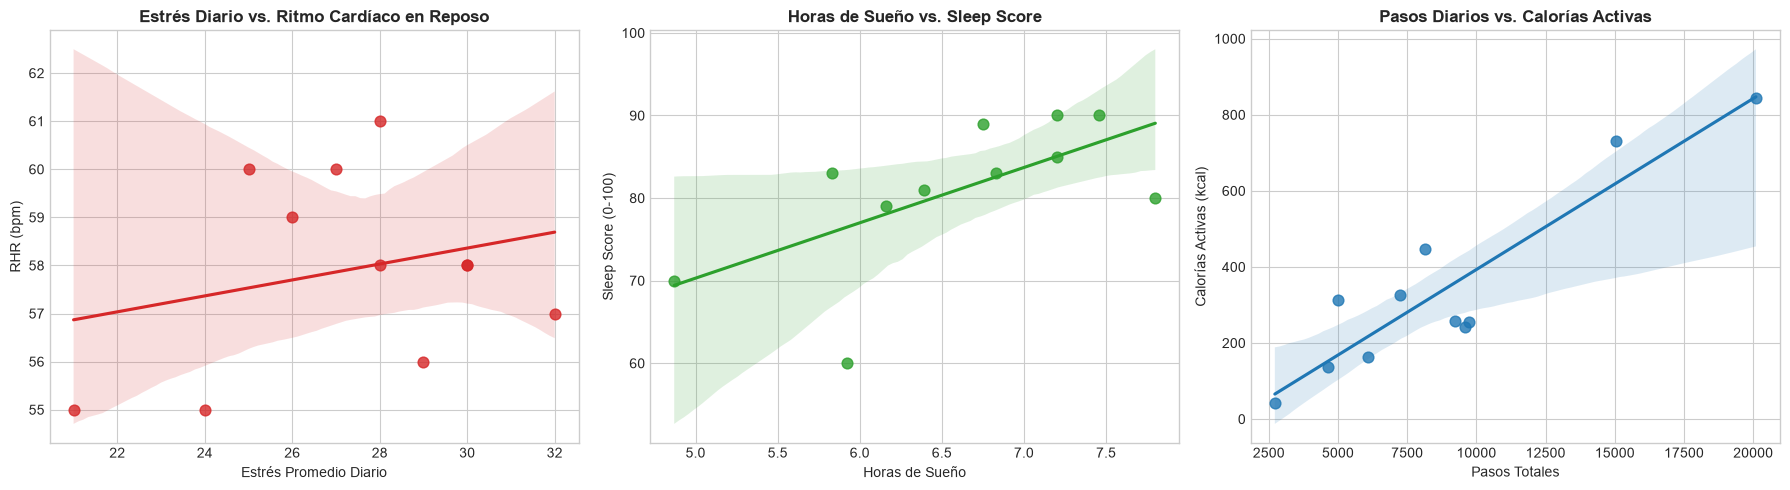

In [3]:
# 2. Correlaciones Clave Destacadas: Gráficos de Dispersión con Regresión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stress vs Resting HR
sns.regplot(data=df, x="daily_avg_stress", y="resting_heart_rate", ax=axes[0], color="#d62728", scatter_kws={"s": 60})
axes[0].set_title("Estrés Diario vs. Ritmo Cardíaco en Reposo", fontweight="bold")
axes[0].set_xlabel("Estrés Promedio Diario")
axes[0].set_ylabel("RHR (bpm)")

# Sleep Hours vs Sleep Score
sns.regplot(data=df, x="total_sleep_hours", y="sleep_score", ax=axes[1], color="#2ca02c", scatter_kws={"s": 60})
axes[1].set_title("Horas de Sueño vs. Sleep Score", fontweight="bold")
axes[1].set_xlabel("Horas de Sueño")
axes[1].set_ylabel("Sleep Score (0-100)")

# Active Calories vs Total Steps
sns.regplot(data=df, x="total_steps", y="active_kilocalories", ax=axes[2], color="#1f77b4", scatter_kws={"s": 60})
axes[2].set_title("Pasos Diarios vs. Calorías Activas", fontweight="bold")
axes[2].set_xlabel("Pasos Totales")
axes[2].set_ylabel("Calorías Activas (kcal)")

plt.tight_layout()
plt.show()


## 💡 Conclusiones del Análisis de Correlación
1. **Acoplamiento metabólico**: Existe una correlación positiva fuerte ($r > 0.85$) entre pasos diarios y calorías activas.
2. **Estrés y Reposo**: Los días con estrés autonómico elevado muestran elevaciones concomitantes en la frecuencia cardíaca en reposo.
3. **Calidad de Sueño**: El `sleep_score` no depende únicamente de la duración en horas, sino de la preservación de fases profundas sin interrupciones por estrés diurno.
